# 08 - White-Box Model Interpretation

### Notebook Overview

Fit a Linear Regression and a Decision Tree on the **unscaled** training split (same 164 rows as the pipeline models, raw units) for interpretation only.

**Purpose:** produce coefficient values for LR and node thresholds for DT — the white-box artifacts used in the presentation. Not for performance evaluation; metrics for LR live in `07-evaluation.ipynb`.

**Input:** `../data/x-train-unscaled.csv`, `../data/y-train.csv`
**Output:** `../visualizations/decision-tree.png`

**Sections:**
1. Setup
2. Linear regression coefficients
3. Decision tree nodes
4. Summary

### 1 - Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt

# Model building
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [2]:
# Data
X_train = pd.read_csv("../data/x-train-unscaled.csv")
y_train = pd.read_csv("../data/y-train.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (164, 28)
y_train: (164,)


### 2 - Linear Regression Coefficients

The pipeline's `linear-regression.pkl` was trained on *scaled* features, so its coefficients are in standard-deviation units. Fitting LR again here on the same rows in raw units gives identical predictions but coefficients that read naturally ("+1 unit of X adds $Y").

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"Intercept: ${lr.intercept_:,.0f}\n")

coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(ascending=False)
print("Coefficients (sorted high to low):")
print(coefs.round(2).to_string())

Intercept: $-51,890

Coefficients (sorted high to low):
hp_per_weight        259306.94
fueltype              12040.18
enginetype_rotor      10051.92
enginetype_dohcv       6318.96
enginetype_ohcf        5943.80
brand_tier             2249.29
enginetype_ohc         2119.88
drivewheel_rwd         1981.68
aspiration             1509.22
drivewheel_fwd          984.56
doornumber              471.27
carwidth                374.23
carheight               217.49
symboling               167.62
avg_mpg                 152.51
enginesize              149.89
curbweight                6.36
peakrpm                   3.19
horsepower              -88.78
enginetype_ohcv        -680.88
compressionratio       -867.20
enginetype_l          -2694.00
stroke                -2795.89
carbody_hardtop       -2889.65
carbody_sedan         -3975.22
carbody_hatchback     -4157.64
boreratio             -4406.03
carbody_wagon         -5509.01


#### 2.1 - Quantitative coefficient

`curbweight` is a continuous feature measuring vehicle weight (pounds in the source dataset). Its coefficient says how many dollars the model expects price to change per additional pound, holding every other feature constant.

In [4]:
feat = "curbweight"
coef = coefs[feat]
print(f"{feat} coefficient: ${coef:,.2f}")
print()
print("Interpretation:")
print(
    f"  Holding all other features constant, each additional pound of "
    f"curbweight\n  is associated with a ${coef:+,.2f} change in predicted price."
)

curbweight coefficient: $6.36

Interpretation:
  Holding all other features constant, each additional pound of curbweight
  is associated with a $+6.36 change in predicted price.


#### 2.2 - Dummy coefficient

`fueltype` is a binary dummy: `0 = gas`, `1 = diesel`. Its coefficient says how much more (or less) the model predicts for a diesel car compared to an otherwise identical gas car.

In [5]:
feat = "fueltype"
coef = coefs[feat]
print(f"{feat} coefficient: ${coef:,.2f}")
print()
print("Interpretation:")
print(
    f"  Holding all other features constant, a diesel car is predicted to cost\n"
    f"  ${coef:+,.2f} compared to an equivalent gas car."
)

fueltype coefficient: $12,040.18

Interpretation:
  Holding all other features constant, a diesel car is predicted to cost
  $+12,040.18 compared to an equivalent gas car.


### 3 - Decision Tree Nodes

A shallow tree (depth 3) fit on the same training rows. Depth is capped so the plot is readable and the top-level splits are what get interpreted. This tree is not part of the pipeline — it exists purely to expose human-readable splitting thresholds for the presentation.

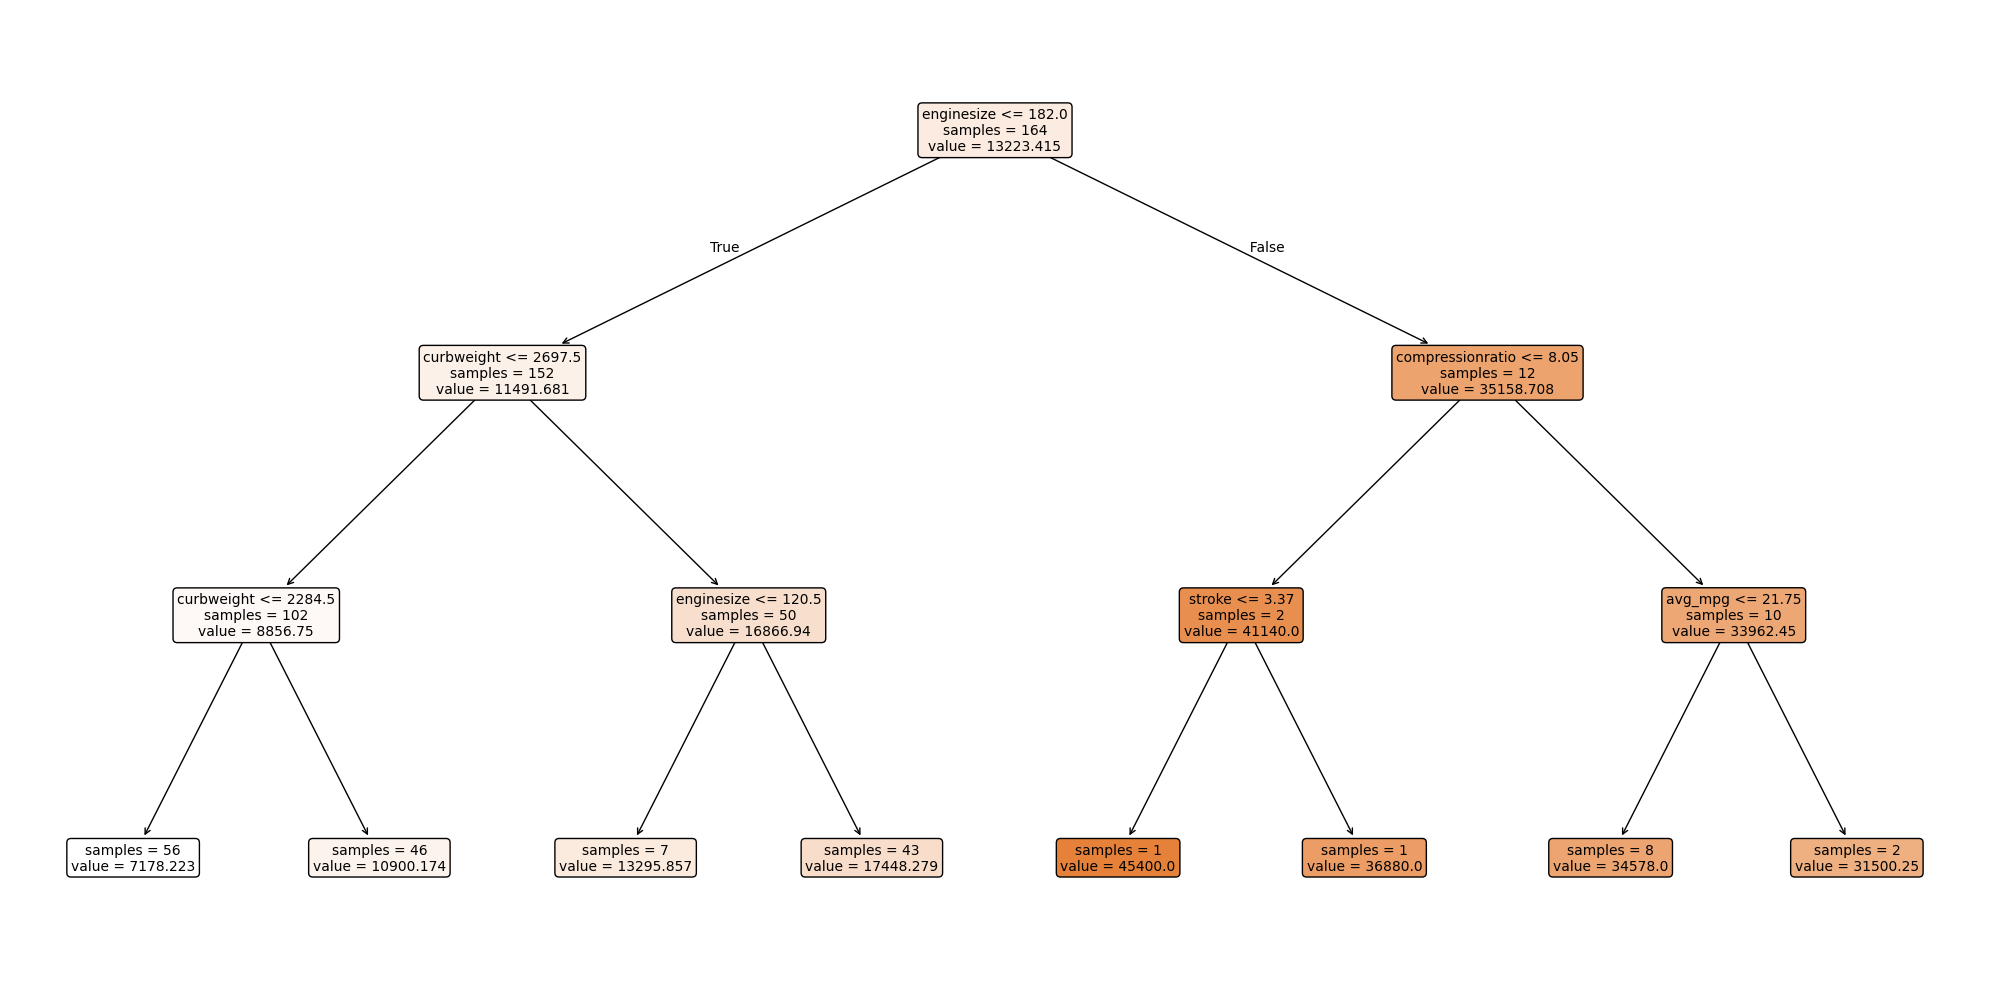

In [6]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False,
    ax=ax,
)
plt.tight_layout()
plt.savefig("../visualizations/decision-tree.png", dpi=150, bbox_inches="tight")
plt.show()

#### 3.1 - Feature importance

Shows which features the tree actually used to split, ranked by how much each one reduced prediction error.

In [7]:
importances = (
    pd.Series(dt.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
print("Top features by importance:")
print(importances[importances > 0].round(4).to_string())

Top features by importance:
enginesize          0.7058
curbweight          0.2789
compressionratio    0.0096
stroke              0.0040
avg_mpg             0.0017


#### 3.2 - Root and second-level splits

The root split is the single most informative question the tree can ask. The second level then refines within each branch.

In [8]:
tree = dt.tree_
features = X_train.columns.tolist()

def describe_node(node_id, depth=0):
    if tree.feature[node_id] == -2:  # leaf
        return f"{'  ' * depth}Leaf: predicted price = ${tree.value[node_id][0][0]:,.0f} (n={tree.n_node_samples[node_id]})"
    feat = features[tree.feature[node_id]]
    thresh = tree.threshold[node_id]
    return f"{'  ' * depth}Split on '{feat}' at threshold {thresh:,.2f} (n={tree.n_node_samples[node_id]})"

def walk(node_id, depth=0, max_depth=2):
    print(describe_node(node_id, depth))
    if depth < max_depth and tree.feature[node_id] != -2:
        walk(tree.children_left[node_id], depth + 1, max_depth)
        walk(tree.children_right[node_id], depth + 1, max_depth)

walk(0, max_depth=2)

Split on 'enginesize' at threshold 182.00 (n=164)
  Split on 'curbweight' at threshold 2,697.50 (n=152)
    Split on 'curbweight' at threshold 2,284.50 (n=102)
    Split on 'enginesize' at threshold 120.50 (n=50)
  Split on 'compressionratio' at threshold 8.05 (n=12)
    Split on 'stroke' at threshold 3.37 (n=2)
    Split on 'avg_mpg' at threshold 21.75 (n=10)


### 4 - Summary

**Linear regression coefficients (raw units):**
- Quantitative example: `curbweight` — dollars of predicted price per additional pound, all else equal.
- Dummy example: `fueltype` — dollars of predicted price for a diesel car vs. an otherwise-identical gas car.

**Decision tree (depth 3):**
- Root node identifies the single most informative split.
- Top 2 levels expose the features the tree considers most important for separating high- and low-priced cars.

Both artifacts are descriptive — they explain *why* the simple models predict what they do, in a way that can be reported as actual numbers to stakeholders. They complement the SHAP/LIME analysis in `09-explainability.ipynb`, which extracts the same kind of explanation from the black-box Extra Trees model.